#Neurals (Advances Machine Learning)
# PawMatch
### Aicha Dieng


# Business Context

PawMatch is a pet social app where owners create profiles for their cats and dogs to find playmates and arrange meetups. Every day, hundreds of pet photos get uploaded to the platform.

The problem is that before any profile goes live, the app needs to know if the pet is a cat or a dog. Get it wrong and cats start showing up in the dog feed, wrong matches get made, and users get frustrated fast.

Manually reviewing every uploaded photo just doesn't scale. So the fix is a binary image classifier that automatically identifies whether a photo is a cat or a dog the moment someone uploads it.

That's what we're building. Using the CIFAR-10 dataset, we filter the data down to cats and dogs only, train a CNN on those labeled images, test three different configurations by tuning hyperparameters, and identify which setup gives PawMatch the most accurate and reliable pet detection.

## Data Loading & Processing

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [2]:
# Load CIFAR10 dataset
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset_full = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# CIFAR10 class indices: cat=3, dog=5
# Filter to keep only cats and dogs
cat_dog_classes = [3, 5]

train_indices = [i for i, label in enumerate(trainset_full.targets) if label in cat_dog_classes]
test_indices = [i for i, label in enumerate(testset_full.targets) if label in cat_dog_classes]

trainset = torch.utils.data.Subset(trainset_full, train_indices)
testset = torch.utils.data.Subset(testset_full, test_indices)

# Remap labels: cat=0, dog=1
classes = ['cat', 'dog']
print("Training samples:", len(trainset))
print("Test samples:", len(testset))

100%|██████████| 170M/170M [03:00<00:00, 945kB/s]


Training samples: 10000
Test samples: 2000


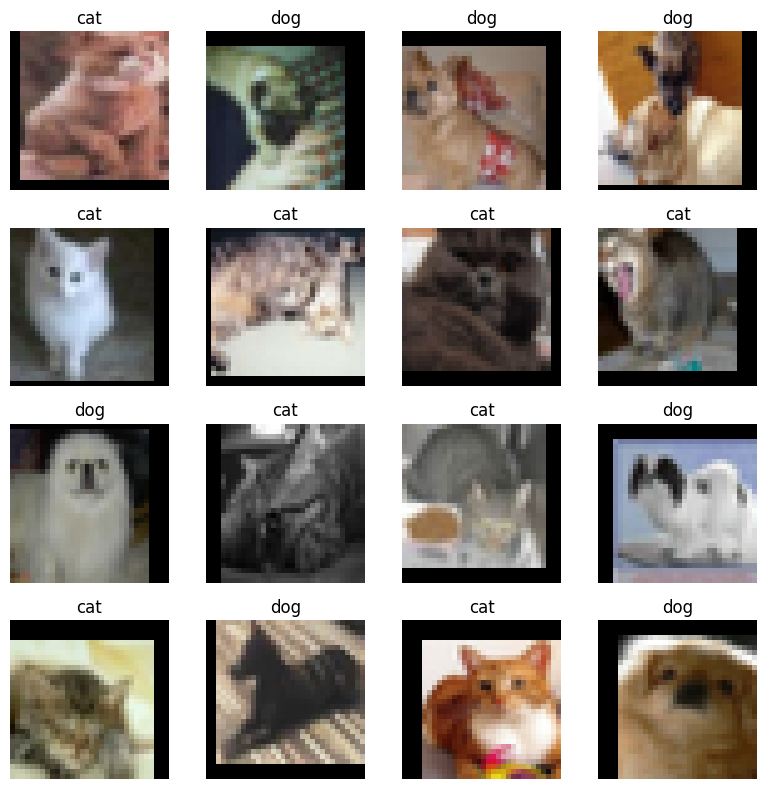

In [3]:
# Visualize sample images
trainloader_vis = torch.utils.data.DataLoader(trainset, batch_size=16, shuffle=True)
images, labels = next(iter(trainloader_vis))

# Map original CIFAR10 labels to binary: 3=cat→0, 5=dog→1
label_map = {3: 0, 5: 1}
classes = ['cat', 'dog']

fig = plt.figure(figsize=(8,8))
for i in range(16):
    ax = fig.add_subplot(4,4,i+1)
    img = images[i] / 2 + 0.5
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg,(1,2,0)))
    ax.set_title(classes[label_map[labels[i].item()]])
    ax.axis("off")
plt.tight_layout()
plt.show()

In [4]:
# Remap labels: cat(3) → 0, dog(5) → 1
def remap_labels(subset):
    label_map = {3: 0, 5: 1}
    subset.dataset.targets = [
        label_map[t] if t in label_map else t
        for t in subset.dataset.targets
    ]

remap_labels(trainset)
remap_labels(testset)

print("Labels remapped: cat=0, dog=1")

Labels remapped: cat=0, dog=1


## Model Training

In [5]:
# ==========================
# TUNE THESE PARAMETERS - MODEL 1 BASELINE
# ==========================

BATCH_SIZE = 128
# how many images at one
LEARNING_RATE = 0.001
# lower the better
EPOCHS = 10
# Higher the better - smaller subsets to refine

CONV_CHANNELS = [32, 64, 128]   # Try [64,128,256] -- number of nodes in the hidden layer
HIDDEN_UNITS = 256              # Try 512 - more units you have within the layers, better the accuracy
DROPOUT_RATE = 0.3              # Try 0.5 - the lower dropout, the better the model
KERNEL_SIZE = 3                 # smaller the better - Filter
NUM_CLASSES = 2                 # Binary: cat=0, dog=1

In [6]:
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [7]:
class CNN(nn.Module):
    def __init__(
        self,
        conv_channels,
        kernel_size,
        dropout_rate,
        hidden_units,
        num_classes=2
    ):
        super().__init__()

        layers = []
        in_channels = 3
        current_size = 32

        for out_channels in conv_channels:
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, padding=1))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(2))

            in_channels = out_channels
            current_size //= 2

        self.features = nn.Sequential(*layers)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_channels * current_size * current_size, hidden_units),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_units, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# Model 1 - The Baseline

In [8]:

model = CNN(
    conv_channels=CONV_CHANNELS,
    kernel_size=KERNEL_SIZE,
    dropout_rate=DROPOUT_RATE,
    hidden_units=HIDDEN_UNITS,
    num_classes=NUM_CLASSES
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)


In [9]:
def train_epoch():
    model.train()
    correct, total, running_loss = 0, 0, 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss/len(trainloader), 100.*correct/total


def test_epoch():
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return 100.*correct/total

In [10]:
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch()
    test_acc = test_epoch()

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print("-"*40)

Epoch 1
Train Loss: 0.6781
Train Accuracy: 57.39%
Test Accuracy: 60.45%
----------------------------------------
Epoch 2
Train Loss: 0.6319
Train Accuracy: 64.53%
Test Accuracy: 66.00%
----------------------------------------
Epoch 3
Train Loss: 0.5869
Train Accuracy: 69.08%
Test Accuracy: 70.80%
----------------------------------------
Epoch 4
Train Loss: 0.5570
Train Accuracy: 71.52%
Test Accuracy: 71.45%
----------------------------------------
Epoch 5
Train Loss: 0.5338
Train Accuracy: 73.42%
Test Accuracy: 68.15%
----------------------------------------
Epoch 6
Train Loss: 0.5103
Train Accuracy: 74.64%
Test Accuracy: 76.95%
----------------------------------------
Epoch 7
Train Loss: 0.4930
Train Accuracy: 75.72%
Test Accuracy: 78.10%
----------------------------------------
Epoch 8
Train Loss: 0.4780
Train Accuracy: 76.49%
Test Accuracy: 76.60%
----------------------------------------
Epoch 9
Train Loss: 0.4689
Train Accuracy: 77.39%
Test Accuracy: 78.90%
------------------------

For Model 1, I intentionally kept all hyperparameters at their default values. The reasoning is: before making any changes, I needed a reference point. There is no way to know whether a lower learning rate improves performance or whether more epochs help without first seeing what standard settings produce.

The model runs 3 convolutional layers, each followed by ReLU and MaxPool. The first layer picks up simple patterns like edges and color contrasts, things that are easy to detect in any image. The second layer builds on that and starts detecting shapes. The third layer goes deeper into the complex features like fur texture and ear structure, details that actually separate a cat from a dog.

After each layer, ReLU removes any negative values that don't contribute to learning, and MaxPool shrinks the image down while keeping only the strongest signals. This keeps the model focused on what matters without getting overwhelmed by noise.

For PawMatch, this matters. A photo uploaded by a user could be taken in bad lighting, from a different angle, or with a cluttered background. The model needs to look past all of that and focus on the actual animal.

I chose a learning rate of 0.001 because it sits in a safe middle ground. A higher rate risks the model overcorrecting every time it makes a mistake, which leads to unstable training. A lower rate means it barely adjusts, and 10 epochs would not be enough to learn anything meaningful. 0.001 gives it room to actually learn without going off track.

Batch size 128 was chosen to keep training stable. Looking at 128 images before updating means the model is not reacting to every single image individually, which would make learning erratic. It averages what it sees across a reasonable number of examples before deciding how to adjust.

Dropout of 0.3 was kept low for the baseline. The goal at this stage was not to stress test the model; it was to see what it could do under normal conditions. Turning off only 30% of neurons still prevents memorization without making learning unnecessarily difficult. This is important for PawMatch since the model will eventually need to correctly classify photos it has never seen before, not just the ones it trained on.

Conv channels [32, 64, 128] start small and grow with each layer because the patterns the model needs to detect get more complex as it goes deeper.
32 filters is enough to catch basic edges and color differences. By layer 3, the model needs 128 filters to detect things like the curve of an ear or the texture of fur, features that actually separate cats from dogs.

The results confirmed this was a solid foundation. Loss dropped consistently from 0.68 to 0.46 and test accuracy reached 78.60%, close to train accuracy of 78.05%, which means the model is generalizing well and not just memorizing training images.

# Model 2

In [11]:
BATCH_SIZE = 64
LEARNING_RATE = 0.0001
EPOCHS = 12
CONV_CHANNELS = [32, 64, 128]
HIDDEN_UNITS = 256
DROPOUT_RATE = 0.5
KERNEL_SIZE = 3
NUM_CLASSES = 2

In [12]:
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [13]:
model = CNN(
    conv_channels=CONV_CHANNELS,
    kernel_size=KERNEL_SIZE,
    dropout_rate=DROPOUT_RATE,
    hidden_units=HIDDEN_UNITS,
    num_classes=NUM_CLASSES
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [14]:
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch()
    test_acc = test_epoch()

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print("-"*40)

Epoch 1
Train Loss: 0.6826
Train Accuracy: 56.11%
Test Accuracy: 59.55%
----------------------------------------
Epoch 2
Train Loss: 0.6656
Train Accuracy: 59.45%
Test Accuracy: 61.70%
----------------------------------------
Epoch 3
Train Loss: 0.6536
Train Accuracy: 61.57%
Test Accuracy: 66.05%
----------------------------------------
Epoch 4
Train Loss: 0.6451
Train Accuracy: 63.21%
Test Accuracy: 64.40%
----------------------------------------
Epoch 5
Train Loss: 0.6241
Train Accuracy: 65.31%
Test Accuracy: 65.30%
----------------------------------------
Epoch 6
Train Loss: 0.6105
Train Accuracy: 66.47%
Test Accuracy: 68.90%
----------------------------------------
Epoch 7
Train Loss: 0.6012
Train Accuracy: 67.63%
Test Accuracy: 71.60%
----------------------------------------
Epoch 8
Train Loss: 0.5852
Train Accuracy: 69.59%
Test Accuracy: 72.35%
----------------------------------------
Epoch 9
Train Loss: 0.5703
Train Accuracy: 70.79%
Test Accuracy: 69.25%
------------------------

Model 2 was testing whether slowing the learning process down would lead to more precise results. Model 1 performed well but I wanted to see if the model was moving too fast and potentially missing a better solution. The changes made were deliberate: lower learning rate, higher dropout, smaller batch size, and two additional epochs.

The architecture remains the same: 3 convolutional layers each followed by ReLU and MaxPool, detecting increasingly complex patterns from edges to shapes to fur texture and ear structure. What changed is how the model learns, not what it learns from.

I dropped the learning rate from 0.001 to 0.0001 to make the model take smaller, more careful steps each time it corrected itself. The idea was that smaller corrections would lead to a more precise final result. In practice, it made the model learn significantly slower. By epoch 12, it still hadn't reached where Model 1 was by epoch 7. For PawMatch, a model that learns slowly is not ideal if we ever need to retrain on new data quickly.

Batch size was reduced from 128 to 64 so the model updates itself more frequently, which I expected to compensate for the slower learning rate. It helped stabilize training but wasn't enough to close the gap with Model 1.

Dropout was increased from 0.3 to 0.5, meaning 50% of neurons are randomly switched off during training. The intention was to force the model to generalize better and not rely on specific neurons. However, combined with the low learning rate, this made learning too difficult; the model was both taking tiny steps and working with half its neurons at a time.

Test accuracy fluctuated between epochs 8 and 10, dropping from 72.35% to 69.25% before recovering to 73.75%. This instability is a direct consequence of the low learning rate combined with high dropout. The model was not adjusting confidently enough to move in a consistent direction.

The final test accuracy of 74.75% confirms that this configuration underperformed compared to Model 1's 78.60%. The lesson here is that slower and more restricted does not always mean better. In this case it just meant slower and worse.

# Model 3

In [15]:
# ==========================
# MODEL 3 - OPTIMIZED
# ==========================
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 15
CONV_CHANNELS = [64, 128, 256]
HIDDEN_UNITS = 512
DROPOUT_RATE = 0.3
KERNEL_SIZE = 3
NUM_CLASSES = 2

In [16]:
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [17]:
model = CNN(
    conv_channels=CONV_CHANNELS,
    kernel_size=KERNEL_SIZE,
    dropout_rate=DROPOUT_RATE,
    hidden_units=HIDDEN_UNITS,
    num_classes=NUM_CLASSES
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [18]:
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch()
    test_acc = test_epoch()

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print("-"*40)

Epoch 1
Train Loss: 0.6707
Train Accuracy: 57.69%
Test Accuracy: 64.05%
----------------------------------------
Epoch 2
Train Loss: 0.6150
Train Accuracy: 66.40%
Test Accuracy: 71.70%
----------------------------------------
Epoch 3
Train Loss: 0.5710
Train Accuracy: 70.42%
Test Accuracy: 68.75%
----------------------------------------
Epoch 4
Train Loss: 0.5375
Train Accuracy: 72.19%
Test Accuracy: 74.40%
----------------------------------------
Epoch 5
Train Loss: 0.5164
Train Accuracy: 74.15%
Test Accuracy: 72.60%
----------------------------------------
Epoch 6
Train Loss: 0.4886
Train Accuracy: 76.09%
Test Accuracy: 78.00%
----------------------------------------
Epoch 7
Train Loss: 0.4804
Train Accuracy: 76.33%
Test Accuracy: 78.20%
----------------------------------------
Epoch 8
Train Loss: 0.4640
Train Accuracy: 77.48%
Test Accuracy: 78.55%
----------------------------------------
Epoch 9
Train Loss: 0.4461
Train Accuracy: 78.92%
Test Accuracy: 78.35%
------------------------

Model 3 was built on the lessons from the first two. Model 1 showed that a learning rate of 0.001 works well. Model 2 showed that slowing it down too much and increasing dropout too aggressively hurts performance. Model 3 takes what worked, fixes what didn't, and pushes what hadn't been fully tested yet.

The architecture runs the same 3 convolutional layers followed by ReLU and MaxPool, but with a key difference: the conv channels were doubled from [32, 64, 128] to [64, 128, 256]. This means each layer now has twice as many filters detecting patterns. Layer 1 picks up more variations of edges and color contrasts, layer 2 detects more shape combinations, and layer 3 has 256 filters working to identify complex features like fur texture, ear shape, and facial structure. For PawMatch specifically, cats and dogs share a lot of visual similarities: four legs, two ears, and similar fur. The difference is in the details, and more filters means the model has more capacity to detect those details.

The learning rate was kept at 0.001 because Model 1 proved this was the right pace; fast enough to learn meaningfully in a reasonable number of epochs, stable enough not to overshoot.

Dropout was kept at 0.3 for the same reason, Model 2 proved that 0.5 made learning too difficult when combined with other constraints.

Epochs were increased from 10 to 15 because Model 1 was still improving at epoch 10(it had not plateaued yet). Giving the model 5 more passes through the data allowed it to keep refining what it had learned.

The batch size was reduced from 128 to 32, meaning the model updates itself more frequently. Combined with the right learning rate, this leads to more precise adjustments without the instability seen in Model 2.

The trade-off is training time. Model 3 took significantly longer to run than Models 1 and 2. However for PawMatch, training happens once before deployment. A longer training time is an acceptable cost if it means the model correctly identifies more cats and dogs once it goes live.

The results speak for themselves as Loss dropped from 0.67 to 0.40 and test accuracy reached 81.85% (the highest across all three models) and a clear improvement over Model 1's 78.60%. This is the configuration PawMatch should deploy.


# Business Insight :

In [19]:
import pandas as pd

data = {
    'Model': ['Model 1 - Baseline', 'Model 2 - Tuned', 'Model 3 - Optimized'],
    'Learning Rate': [0.001, 0.0001, 0.001],
    'Epochs': [10, 12, 15],
    'Batch Size': [128, 64, 32],
    'Dropout': [0.3, 0.5, 0.3],
    'Conv Channels': ['[32,64,128]', '[32,64,128]', '[64,128,256]'],
    'Train Accuracy': ['78.05%', '72.56%', '81.44%'],
    'Test Accuracy': ['78.60%', '74.75%', '81.85%']
}

df = pd.DataFrame(data)
df

,Model,Learning Rate,Epochs,Batch Size,Dropout,Conv Channels,Train Accuracy,Test Accuracy
0,Model 1 - Baseline,0.0010,10,128,0.3,"[32,64,128]",78.05%,78.60%
1,Model 2 - Tuned,0.0001,12,64,0.5,"[32,64,128]",72.56%,74.75%
2,Model 3 - Optimized,0.0010,15,32,0.3,"[64,128,256]",81.44%,81.85%


Across three experiments, the results make a clear case for Model 3 as the configuration PawMatch should move forward with. With a test accuracy of 81.85%, it outperformed both the baseline and the tuned version.

Model 2 was a necessary experiment. It confirmed that slowing the learning process down and restricting the model too aggressively does not lead to better results, making the model slower and less accurate. That finding directly shaped Model 3, where the learning rate was restored, dropout was kept conservative, and the real changes were made where they actually mattered: more filters to detect finer patterns, more epochs to give the model time to use them, and smaller batches for more precise updates.

For PawMatch, an 81.85% accuracy means that roughly 8 out of every 10 photos uploaded get correctly classified on the first try. That is meaningful at scale. If PawMatch receives 1,000 photo uploads a day, a model with 78.60% accuracy misclassifies around 214 of them. Model 3 brings that down to around 185 (29 fewer wrong matches per day), without any change to the app itself.

The remaining misclassifications are worth acknowledging. No model is perfect, and photos taken in poor lighting, unusual angles, or with obscured faces will always be harder to classify. A production deployment of PawMatch would benefit from a confidence threshold. If the model is not sure enough, the photo gets flagged for manual review rather than auto-classified. This keeps the user experience clean while accounting for the model's limitations.

The takeaway is that hyperparameter tuning is not about trying everything; it is about learning from each experiment and making smarter decisions with each iteration.